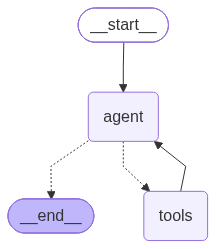

Invoke 2
================================ Human Message =================================

E1001为什么没有年假？
================================== Ai Message ==================================

[{'data': 'gAAAAABqforT79W7FOYip8yxoe_NW4zi8zxsOVsN0jEvrRu7hpZe05RKOuilPvr3uEThhD3trUBdkCdsdZbw3GuUCf8anhHEfZSlkntNf5ezhpTkJLYRUNBp9X-MBd9CSsf4fluLVlRqtXFisxatPluNcEi5iZwsOMKbkvzk0VVmFVQCEATf5Ly0Z9xl58fgQcDFBCyrDbjI3iMcIg7pKF9BQjALILUGh90peQ876VuJVAnohRU2m-Z13eEUqWiU6wdF8JPEObjAkhwMy4ddkS61UlaQH0aCdTNYnPDYFH-RJG_-l--VPMupEdwxlXr0S-oHKREPJg9LyNTR_ZCznPfy6v-HAiswzKBFopHtn7x-uuLDvxOhjEha3btsPc3GLjfMuIrbqSmh6VF7GcjYIiAin4KA-eaLHPmrR8cOI0i-DubwCsOGZ2RGuerKgK66nDSpAxjlW93z030TO90eGFimWrmHza5eyDpTrtWoFwid4SrsJ3edHVzasvtpFSvKgU5jzxJ2wvUAMWSKy0lqPnNvKC-LOhQ9NtXuyXtvuxCmU9dzWYhJCY4n-ifEKungXl5L2GqjC5u2tch7nOaC_LNOS6vLZDAaY3GJEASK9tX1iuPrJNvXBSDbSGoQsVB4vmHpfGO8yfIb5AUx2dUFGruytiscyMVgZDnt-Hn-KTDwW5wt80AnN5eFnoGiEIM_rs-RFymmzIXIEgC5s80FV6glOFtt0DDMF0PAohe7iIF3p-MPsG2cvr0ex71GrYSD4Wje9IOUxL5RCFKStOU0tYeeBf52rQMt8E

In [12]:

import os
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from langchain_core.documents import Document
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings


if "ANTHROPIC_AUTH_TOKEN" in os.environ and "ANTHROPIC_API_KEY" not in os.environ:
    os.environ["ANTHROPIC_API_KEY"] = os.environ["ANTHROPIC_AUTH_TOKEN"]

model = init_chat_model(
    "claude-sonnet-5",
    model_provider="anthropic",
    temperature=0
)



# 1. 准备 Document
documents = [
    Document(
        page_content="试用期员工不享受带薪年假。",
        metadata={
            "source": "员工手册2026",
            "page": 23,
            "status": "active",
            "year": 2026,
        },
    ),
    Document(
        page_content="正式员工每年享有10天带薪年假。",
        metadata={
            "source": "员工手册2026",
            "page": 23,
            "status": "active",
            "year": 2026,
        },
    ),
    Document(
        page_content="单笔报销超过5000元，需要部门负责人审批。",
        metadata={
            "source": "财务制度2026",
            "page": 12,
            "status": "active",
            "year": 2026,
        },
    ),
    Document(
    page_content="试用期员工享有3天带薪年假。",
    metadata={
        "source": "员工手册2024",
        "page": 20,
        "status": "archived",
        "year": 2024,
    },
    )
]



# 2. 初始化 Embedding
embeddings = OpenAIEmbeddings(
    model="qwen3.7-text-embedding",  # 1. 必须写成关键字参数 model=
    openai_api_base="https://llm-v4mqkweosjvc0she.cn-beijing.maas.aliyuncs.com/compatible-mode/v1",
    check_embedding_ctx_length=False,  # 2. 阿里云 DashScope 兼容接口必须加上此项
)

# 3. 初始化 InMemoryVectorStore
vector_store = InMemoryVectorStore(
    embedding=embeddings
)

# 4. add_documents
vector_store.add_documents(documents)

# 5. similarity_search
query = "我还没转正，能休假吗？"
#query = "公司有没有火星移民补贴？"
# 过滤出高于阈值的有效文档

SCORE_THRESHOLD = 0.7

def retrieve_company_knowledge(query: str) -> dict:
    results = vector_store.similarity_search_with_score(
        query,
        k=3,
        filter=lambda doc:
            doc.metadata.get("status") == "active"
            and doc.metadata.get("year") == 2026
    )

    valid_results = [
        (doc, score)
        for doc, score in results
        if score >= SCORE_THRESHOLD
    ]

    if not valid_results:
        return {
            "status": "NO_RELEVANT_KNOWLEDGE",
            "results": []
        }

    return {
        "status": "OK",
        "results": [
            {
                "content": doc.page_content,
                "score": score,
                "source": doc.metadata.get("source"),
                "page": doc.metadata.get("page"),
                "year": doc.metadata.get("year"),
            }
            for doc, score in valid_results
        ]
    }


@tool
def search_company_knowledge(query: str) -> dict:
    """搜索公司制度、员工手册和内部规范。"""
    return retrieve_company_knowledge(query)


EMPLOYEE_DB = {
    "E1001": {
        "name": "张三",
        "status": "probation",
        "annual_leave_balance": 0,
        "department": "研发部",
    },

    "E1002": {
        "name": "李四",
        "status": "regular",
        "annual_leave_balance": 7,
        "department": "财务部",
    },
}


@tool
def query_employee(employee_id: str) -> dict:
    """查询员工当前实时信息，包括员工状态、部门和年假余额。"""

    employee = EMPLOYEE_DB.get(employee_id)

    if employee is None:
        return {
            "error": "employee_not_found"
        }

    return employee

from typing_extensions import TypedDict, Annotated
import operator

from langchain.messages import AnyMessage
from langgraph.graph.message import add_messages
class AgentState(TypedDict):
    messages: Annotated[
        list[AnyMessage],
        add_messages,
    ]


from langchain.messages import ToolMessage
tools = [
    query_employee,
    search_company_knowledge,
]

tools_by_name = {
    tool.name: tool
    for tool in tools
}

model_with_tools = model.bind_tools(tools)

from langchain.messages import SystemMessage

def agent_node(state: AgentState):

    response = model_with_tools.invoke(
        [
            SystemMessage(
                content="""
你是公司内部AI助手。

规则：

1. 员工当前状态、余额等实时信息，使用 query_employee。
2. 公司制度、员工手册、规范，使用 search_company_knowledge。
3. 不允许编造企业内部数据。
4. 如果知识库返回 NO_RELEVANT_KNOWLEDGE，
   必须明确告诉用户没有找到可靠依据。
5. 如果一个问题需要多个数据源，可以调用多个工具。

【重要：工具执行策略 (Planning & Tool Dependency)】
当你遇到复杂问题（如“某人为什么没有年假？”）时，你需要进行逻辑拆解，**串行（分步）**调用工具：
- 第一步：必须先调用 query_employee，获取该员工的具体身份属性（如 status 是 probation 还是 regular）。
- 第二步：拿到员工状态后，根据其状态，再去调用 search_company_knowledge 查询对应的公司制度（如搜索“试用期员工 年假规定”）。
绝对不要在不知道员工状态的情况下，盲目并发调用两个工具！
"""
            )
        ]
        + state["messages"]
    )

    return {
        "messages": [response]
    }









def tool_node(state: AgentState):
    last_message = state["messages"][-1]

    results = []

    for tool_call in last_message.tool_calls:
        tool = tools_by_name[
            tool_call["name"]
        ]

        observation = tool.invoke(
            tool_call["args"]
        )

        results.append(
            ToolMessage(
                content=str(observation),
                tool_call_id=tool_call["id"],
            )
        )

    return {
        "messages": results
    }

    



# Step 5: Define logic to determine whether to end
from typing import Literal
from langgraph.graph import END


def route_after_agent(
    state: AgentState,
) -> Literal["tools", "__end__"]:

    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return END
    



# Step 6: Build agent
from langgraph.graph import (
    START,
    StateGraph,
)


builder = StateGraph(AgentState)

builder.add_node(
    "agent",
    agent_node,
)

builder.add_node(
    "tools",
    tool_node,
)

builder.add_edge(
    START,
    "agent",
)

builder.add_conditional_edges(
    "agent",
    route_after_agent,
    {
        "tools": "tools",
        "__end__": END,
    },
)

builder.add_edge(
    "tools",
    "agent",
)

graph = builder.compile()


from langchain.messages import HumanMessage


from IPython.display import Image, display
# Show the agent
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)


    

# Invoke 1
print("Invoke 1")
result = graph.invoke({
    "messages": [
        HumanMessage(
            content=(
                "E1001为什么没有年假？"
            )
        )
    ]
})

for message in result["messages"]:
    message.pretty_print()